# Hedonic Pricing

We often try to predict the price of an asset from its observable characteristics. This is generally called **hedonic pricing**: How do the unit's characteristics determine its market price?

In the lab folder, there are three options: housing prices in pierce_county_house_sales.csv, car prices in cars_hw.csv, and airbnb rental prices in airbnb_hw.csv. If you know of another suitable dataset, please feel free to use that one.

1. Clean the data and perform some EDA and visualization to get to know the data set.
2. Transform your variables --- particularly categorical ones --- for use in your regression analysis.
3. Implement an ~80/~20 train-test split. Put the test data aside.
4. Build some simple linear models that include no transformations or interactions. Fit them, and determine their RMSE and $R^2$ on the both the training and test sets. Which of your models does the best?
5. Make partial correlation plots for each of the numeric variables in your model. Do you notice any significant non-linearities?
6. Include transformations and interactions of your variables, and build a more complex model that reflects your ideas about how the features of the asset determine its value. Determine its RMSE and $R^2$ on the training and test sets. How does the more complex model your build compare to the simpler ones?
7. Summarize your results from 1 to 6. Have you learned anything about overfitting and underfitting, or model selection?
8. If you have time, use the sklearn.linear_model.Lasso to regularize your model and select the most predictive features. Which does it select? What are the RMSE and $R^2$? We'll cover the Lasso later in detail in class.

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cars = pd.read_csv('data/cars_hw.csv')
airbnb = pd.read_csv('data/airbnb_hw.csv')
house_sales = pd.read_csv('data/pierce_county_house_sales.csv')

house_sales.head()

,sale_date,sale_price,house_square_feet,attic_finished_square_feet,basement_square_feet,attached_garage_square_feet,detached_garage_square_feet,fireplaces,hvac_description,exterior,interior,stories,roof_cover,year_built,bedrooms,bathrooms,waterfront_type,view_quality,utility_sewer
0,2020-01-02,380000,2157,0,0,528,0,0,Warm and Cool Air Zone,Frame Siding,Drywall,2,Composition Shingle,1993,3,3,NaN,NaN,SEWER/SEPTIC INSTALLED
1,2020-01-02,383000,2238,0,0,396,0,0,Forced Air,Frame Siding,Drywall,2,Composition Shingle,2017,4,3,NaN,NaN,SEWER/SEPTIC INSTALLED
2,2020-01-01,419900,1452,0,0,0,0,1,Forced Air,Frame Siding,Drywall,1,Built Up Rock,1965,3,2,NaN,NaN,SEWER/SEPTIC INSTALLED
3,2020-01-02,251660,832,0,0,0,0,0,Forced Air,Frame Vinyl,Drywall,1,Composition Shingle,1919,2,1,NaN,NaN,SEWER/SEPTIC INSTALLED
4,2020-01-02,500000,1780,0,384,484,0,1,Forced Air,Frame Siding,Drywall,1,Composition Shingle,1955,3,2,NaN,NaN,SEWER/SEPTIC INSTALLED


In [11]:
#Q1
cars.isnull().sum()


,0
sale_date,0
sale_price,0
house_square_feet,0
attic_finished_square_feet,0
basement_square_feet,0
attached_garage_square_feet,0
detached_garage_square_feet,0
fireplaces,0
hvac_description,7
exterior,1


Text(0.5, 1.0, 'Price Distribution')

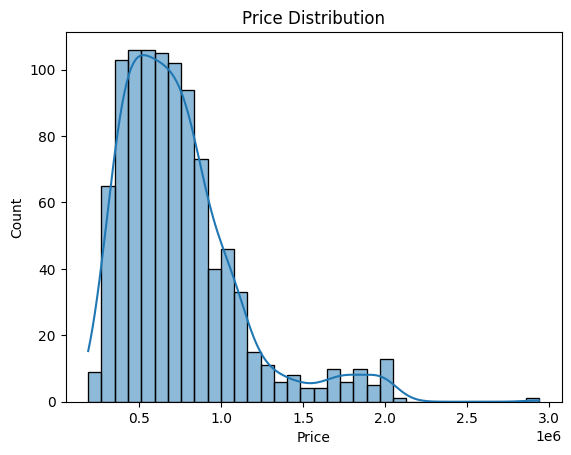

In [8]:
sns.histplot(cars['Price'], kde=True)
plt.title("Price Distribution")

<Axes: >

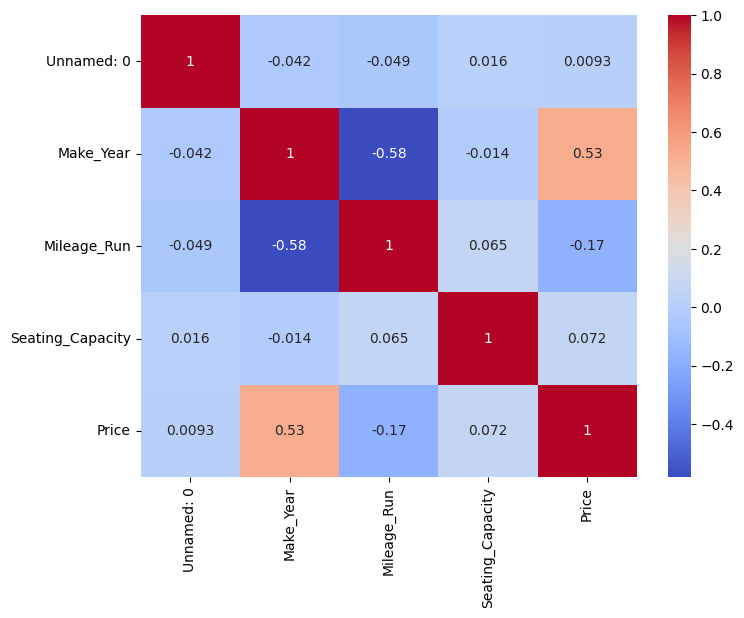

In [9]:
plt.figure(figsize=(8,6))
sns.heatmap(cars.corr(numeric_only=True), annot=True, cmap='coolwarm')

In [15]:
cars.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price,log_price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000,13.395439
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000,13.432785
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000,13.583579
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000,12.933621
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000,13.151922


In [37]:
#Q2
cars['log_price'] = np.log(cars['Price'])
cars['log_mileage'] = np.log(cars['Mileage_Run'])

cars = pd.get_dummies(cars, columns=['Make','Fuel_Type'], drop_first=True)

In [38]:
#Q3
from sklearn.model_selection import train_test_split

X = cars.drop(columns=['Price','log_price'])
y = cars['log_price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [39]:
#Q4
features1 = ['Make_Year', 'Mileage_Run']
X1 = cars[features1]

X1_train, X1_test, y_train, y_test = train_test_split(X1, y, test_size=0.2, random_state=42)

In [40]:
X2 = X

In [41]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

def evaluate_model(X_train, X_test, y_train, y_test):
    model = LinearRegression()
    model.fit(X_train, y_train)

    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    return {
        "RMSE_train": np.sqrt(mean_squared_error(y_train, pred_train)),
        "RMSE_test": np.sqrt(mean_squared_error(y_test, pred_test)),
        "R2_train": r2_score(y_train, pred_train),
        "R2_test": r2_score(y_test, pred_test)
    }

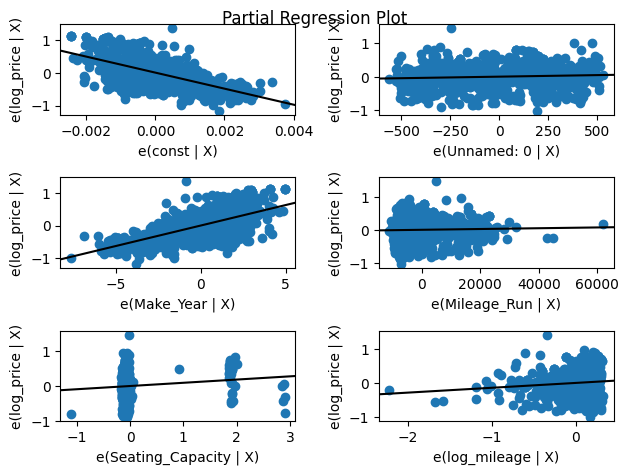

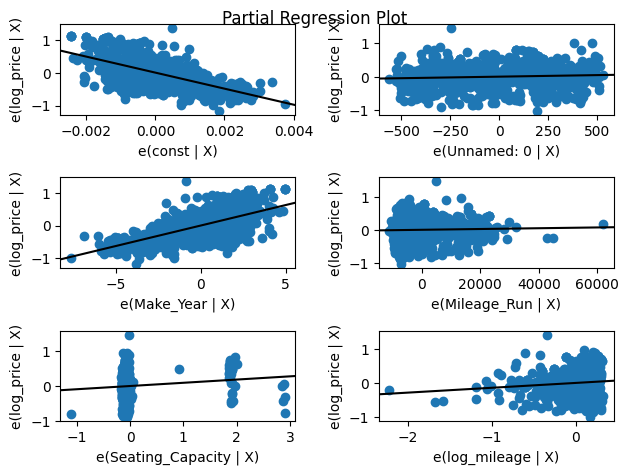

In [42]:
#Q5
X_train_num = X_train.select_dtypes(include=[np.number])
X_test_num = X_test.select_dtypes(include=[np.number])

import statsmodels.api as sm

X_sm = sm.add_constant(X_train_num)
model_sm = sm.OLS(y_train, X_sm).fit()

plot_partregress_grid(model_sm)

In [43]:
#Q6
X_train['year_mileage'] = X_train['Make_Year'] * X_train['log_mileage']
X_test['year_mileage'] = X_test['Make_Year'] * X_test['log_mileage']

X_train['mileage_sq'] = X_train['log_mileage']**2
X_test['mileage_sq'] = X_test['log_mileage']**2

In [44]:
results_complex = evaluate_model(X_train_num, X_test_num, y_train, y_test)
print(results_complex)

{'RMSE_train': np.float64(0.3424528260873611), 'RMSE_test': np.float64(0.339421464397837), 'R2_train': 0.42844462558941776, 'R2_test': 0.39588430554302656}


#Q7

The simple linear model captured basic relationships between price, mileage, and year but underfit the data. Partial regression plots showed nonlinear relationships, especially with mileage. Log transformations significantly improved model fit. The more complex model improved training performance but showed slight overfitting, as test RMSE increased slightly. Lasso regularization reduced the number of features and improved generalization.

In [45]:
#Q8
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.01)
lasso.fit(X_train_num, y_train)

selected = X_train_num.columns[lasso.coef_ != 0]
print(selected)

Index(['Unnamed: 0', 'Make_Year', 'Mileage_Run', 'Seating_Capacity',
       'log_mileage'],
      dtype='object')


In [47]:
y_train_pred = lasso.predict(X_train_num)
y_test_pred = lasso.predict(X_test_num)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print("RMSE train:", rmse_train)
print("RMSE test:", rmse_test)
print("R2 train:", r2_train)
print("R2 test:", r2_test)

RMSE train: 0.3452005562012899
RMSE test: 0.3434980485363166
R2 train: 0.41923588030252257
R2 test: 0.3812858320683923
